In [166]:
import sys
import os
os.environ['USE_PYGEOS'] = '0'

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
from sklearn.metrics import r2_score

import seaborn as sns

# import custom modules
sys.path.append('../../utils')
import data_paths
import traffic_counts
import excel_calendar


In [167]:
# load inventory data

inv = gpd.read_file(data_paths.INVENTORY_PATH + 'linesource_Munich_2019_los_specific.gpkg')
inv['road_type'].unique()

array(['Access-residential', 'Distributor/Secondary', 'Motorway-Nat',
       'TrunkRoad/Primary-National', 'TrunkRoad/Primary-City'],
      dtype=object)

In [168]:
inv.columns

Index(['index', 'road_link_id', 'road_type', 'scaling_road_type',
       'hour_capacity', 'lanes', 'hbefa_speed', 'speed', 'hbefa_gradient',
       'dtv_SUM', 'delta_PC', 'delta_LCV', 'delta_HGV', 'hgv_corr', 'lcv_corr',
       'PC_cold_starts', 'LCV_cold_starts', 'PC_NH3', 'PC_CO', 'PC_NOx',
       'PC_PM', 'PC_PN', 'PC_CO2(rep)', 'PC_CO2(total)', 'PC_NO2', 'PC_CH4',
       'PC_NMHC', 'PC_PM (non-exhaust)', 'PC_Benzene', 'PC_PM2.5',
       'PC_BC (exhaust)', 'PC_PM2.5 (non-exhaust)', 'PC_BC (non-exhaust)',
       'LCV_NH3', 'LCV_CO', 'LCV_NOx', 'LCV_PM', 'LCV_PN', 'LCV_CO2(rep)',
       'LCV_CO2(total)', 'LCV_NO2', 'LCV_CH4', 'LCV_NMHC',
       'LCV_PM (non-exhaust)', 'LCV_Benzene', 'LCV_PM2.5', 'LCV_BC (exhaust)',
       'LCV_PM2.5 (non-exhaust)', 'LCV_BC (non-exhaust)', 'HGV_NH3', 'HGV_CO',
       'HGV_NOx', 'HGV_PM', 'HGV_PN', 'HGV_CO2(rep)', 'HGV_CO2(total)',
       'HGV_NO2', 'HGV_CH4', 'HGV_NMHC', 'HGV_PM (non-exhaust)', 'HGV_Benzene',
       'HGV_PM2.5', 'HGV_BC (exhaust)', 'HG

In [281]:
invs = ['linesource_Munich_2019_los_specific.gpkg',
        'linesource_Munich_2020_los_specific.gpkg', 
        'linesource_Munich_2021_los_specific.gpkg',
        'linesource_Munich_2022_los_specific.gpkg',
        'linesource_Munich_2023_los_specific.gpkg',
        'linesource_Munich_2024_los_specific.gpkg']

selected_road_type = 'TrunkRoad/Primary-City'

df_result = pd.DataFrame()

for i in invs:
    inv = gpd.read_file(data_paths.INVENTORY_PATH + i)
    #inv = inv[inv['road_type']==selected_road_type]
    
    year = i.split('_')[2]
    print(year)
    
    # get total emissions per segment
    inv['CO2'] = inv[['PC_CO2(total)', 'LCV_CO2(total)', 'HGV_CO2(total)', 'MOT_CO2(total)', 'BUS_CO2(total)']].sum(axis=1)
    inv['NOx'] = inv[['PC_NOx', 'LCV_NOx', 'HGV_NOx', 'MOT_NOx', 'BUS_NOx']].sum(axis=1)
    inv['PM'] = inv[['PC_PM', 'LCV_PM', 'HGV_PM', 'MOT_PM', 'BUS_PM']].sum(axis=1)
    inv['PM non-exhaust'] = inv[['PC_PM (non-exhaust)', 'LCV_PM (non-exhaust)', 'HGV_PM (non-exhaust)', 'MOT_PM (non-exhaust)', 'BUS_PM (non-exhaust)']].sum(axis=1)

    # multiply with road length
    inv['CO2'] = inv['CO2'] * inv.geometry.length / 1000  # in kg/m
    inv['NOx'] = inv['NOx'] * inv.geometry.length / 1000  # in kg/m
    inv['PM exhaust'] = inv['PM'] * inv.geometry.length / 1000  # in kg/m
    inv['PM non-exhaust'] = inv['PM non-exhaust'] * inv.geometry.length / 1000  # in kg/m
    
    df_result[year] =inv[['CO2', 'NOx', 'PM exhaust', 'PM non-exhaust']].sum() * 1e-6

df_result.loc['CO2'] = df_result.loc['CO2']*1e-3  # to Mt

2019
2020
2021
2022
2023
2024


Text(0, 0.5, 'CO$_2$ [kt]')

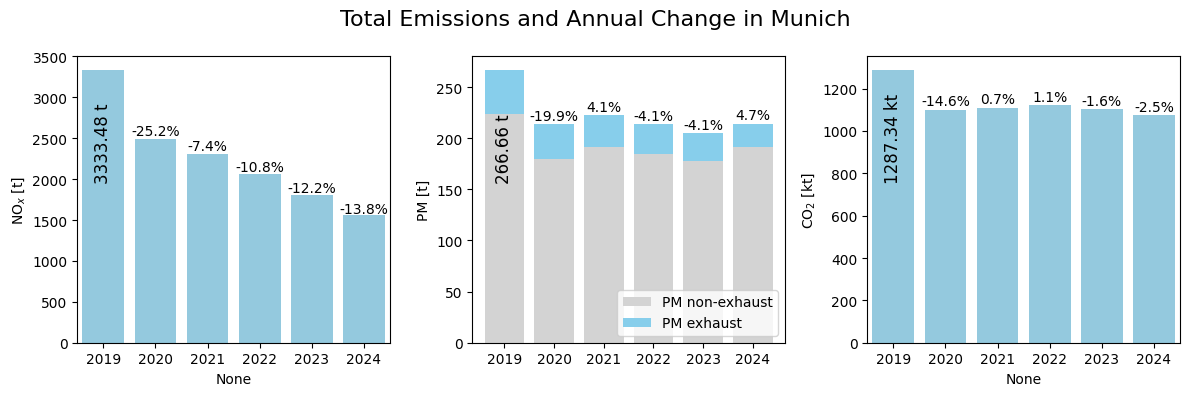

In [283]:
fig, ax = plt.subplots(1,3,figsize=(12,4), tight_layout=True)

#
## NOx
#

sns.barplot(data=df_result.T, x = df_result.T.index, y='NOx', ax=ax[0], color='skyblue')
# add year to year change in percent
df_result_pct = df_result.T.pct_change().multiply(100).round(1)
# add to bar plot
for index, row in df_result_pct.iterrows():
    if index == '2019': 
        total = df_result.T.loc[index]['NOx']
        ax[0].text(index, total*0.6, f"{total:.2f} t", color='black', ha="center", fontsize=12, rotation = 90)
        continue
    ax[0].text(index, df_result.T.loc[index, 'NOx']*1.02, f"{row['NOx']}%", color='black', ha="center")

#
## PM
#

df_result.T[['PM non-exhaust', 'PM exhaust']].plot(kind='bar', stacked=True, ax=ax[1], color=['lightgrey', 'skyblue'], width = 0.8)
ax[1].xaxis.set_tick_params(rotation=0)
ax[1].legend(loc='lower right')

# add year to year change in percent
df_result_pct = df_result.T[['PM non-exhaust', 'PM exhaust']].sum(axis=1).pct_change().multiply(100).round(1)

# add to bar plot
for idx, val in enumerate(df_result_pct.index):
    if val == '2019': 
        total = df_result.T.loc[val][['PM exhaust', 'PM non-exhaust']].sum()
        ax[1].text(idx, total*0.6, f"{total:.2f} t", color='black', ha="center", fontsize=12, rotation = 90)
        continue
    value = df_result.T.loc[val][['PM exhaust', 'PM non-exhaust']].sum()
    ax[1].text(idx, value*1.02, f"{df_result_pct[val]}%", color='black', ha="center")

#
## CO2
# 
    
sns.barplot(data=df_result.T, x = df_result.T.index, y='CO2', ax=ax[2], color='skyblue')
# add year to year change in percent
df_result_pct = df_result.T.pct_change().multiply(100).round(1)
# add to bar plot
for index, row in df_result_pct.iterrows():
    if index == '2019':
        total = df_result.T.loc[index, 'CO2']
        ax[2].text(index, total*0.6, f"{total:.2f} kt", color='black', ha="center", fontsize=12, rotation = 90)
        continue
    ax[2].text(index, df_result.T.loc[index, 'CO2']*1.02, f"{row['CO2']}%", color='black', ha="center")
    

fig.suptitle(f'Total Emissions and Annual Change in Munich', fontsize=16)
ax[0].set_ylabel('NO$_x$ [t]')
ax[1].set_ylabel('PM [t]')
ax[2].set_ylabel('CO$_2$ [kt]')